# Daisyworld: базовая визуализация

Модель «мир маргариток». На клеточной сетке растут чёрные и белые
маргаритки. Чёрные поглощают свет и нагревают поверхность, белые
отражают свет и охлаждают её. Маргаритки размножаются только при
подходящей температуре.

Построим тепловую карту температуры поверхности и покажем на ней
маргаритки в начальный момент, через 5 шагов и ещё через 40 шагов.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
using Agents
using DataFrames
using CairoMakie

Код модели находится в файле `src/daisyworld.jl`:

In [2]:
include(srcdir("daisyworld.jl"))

daisyworld (generic function with 1 method)

## Создание модели

Модель создаётся с параметрами по умолчанию: сетка 30 на 30, по 20%
клеток занято белыми и чёрными маргаритками.

In [3]:
model = daisyworld()

StandardABM with 360 agents of type Daisy
 agents container: Dict
 space: GridSpaceSingle with size (30, 30), metric=chebyshev, periodic=true
 scheduler: fastest
 properties: temperature, solar_luminosity, max_age, surface_albedo, ratio, solar_change, tick, scenario

## Настройка отображения

Цвет маргаритки совпадает с её видом. Фоном служит температура клетки.

In [4]:
daisycolor(a::Daisy) = a.breed

plotkwargs = (
    agent_color = daisycolor, agent_size = 20, agent_marker = '✿',
    heatarray = :temperature,
    heatkwargs = (colorrange = (-20, 60),),
)

(agent_color = Main.daisycolor, agent_size = 20, agent_marker = '✿', heatarray = :temperature, heatkwargs = (colorrange = (-20, 60),))

## Начальное состояние

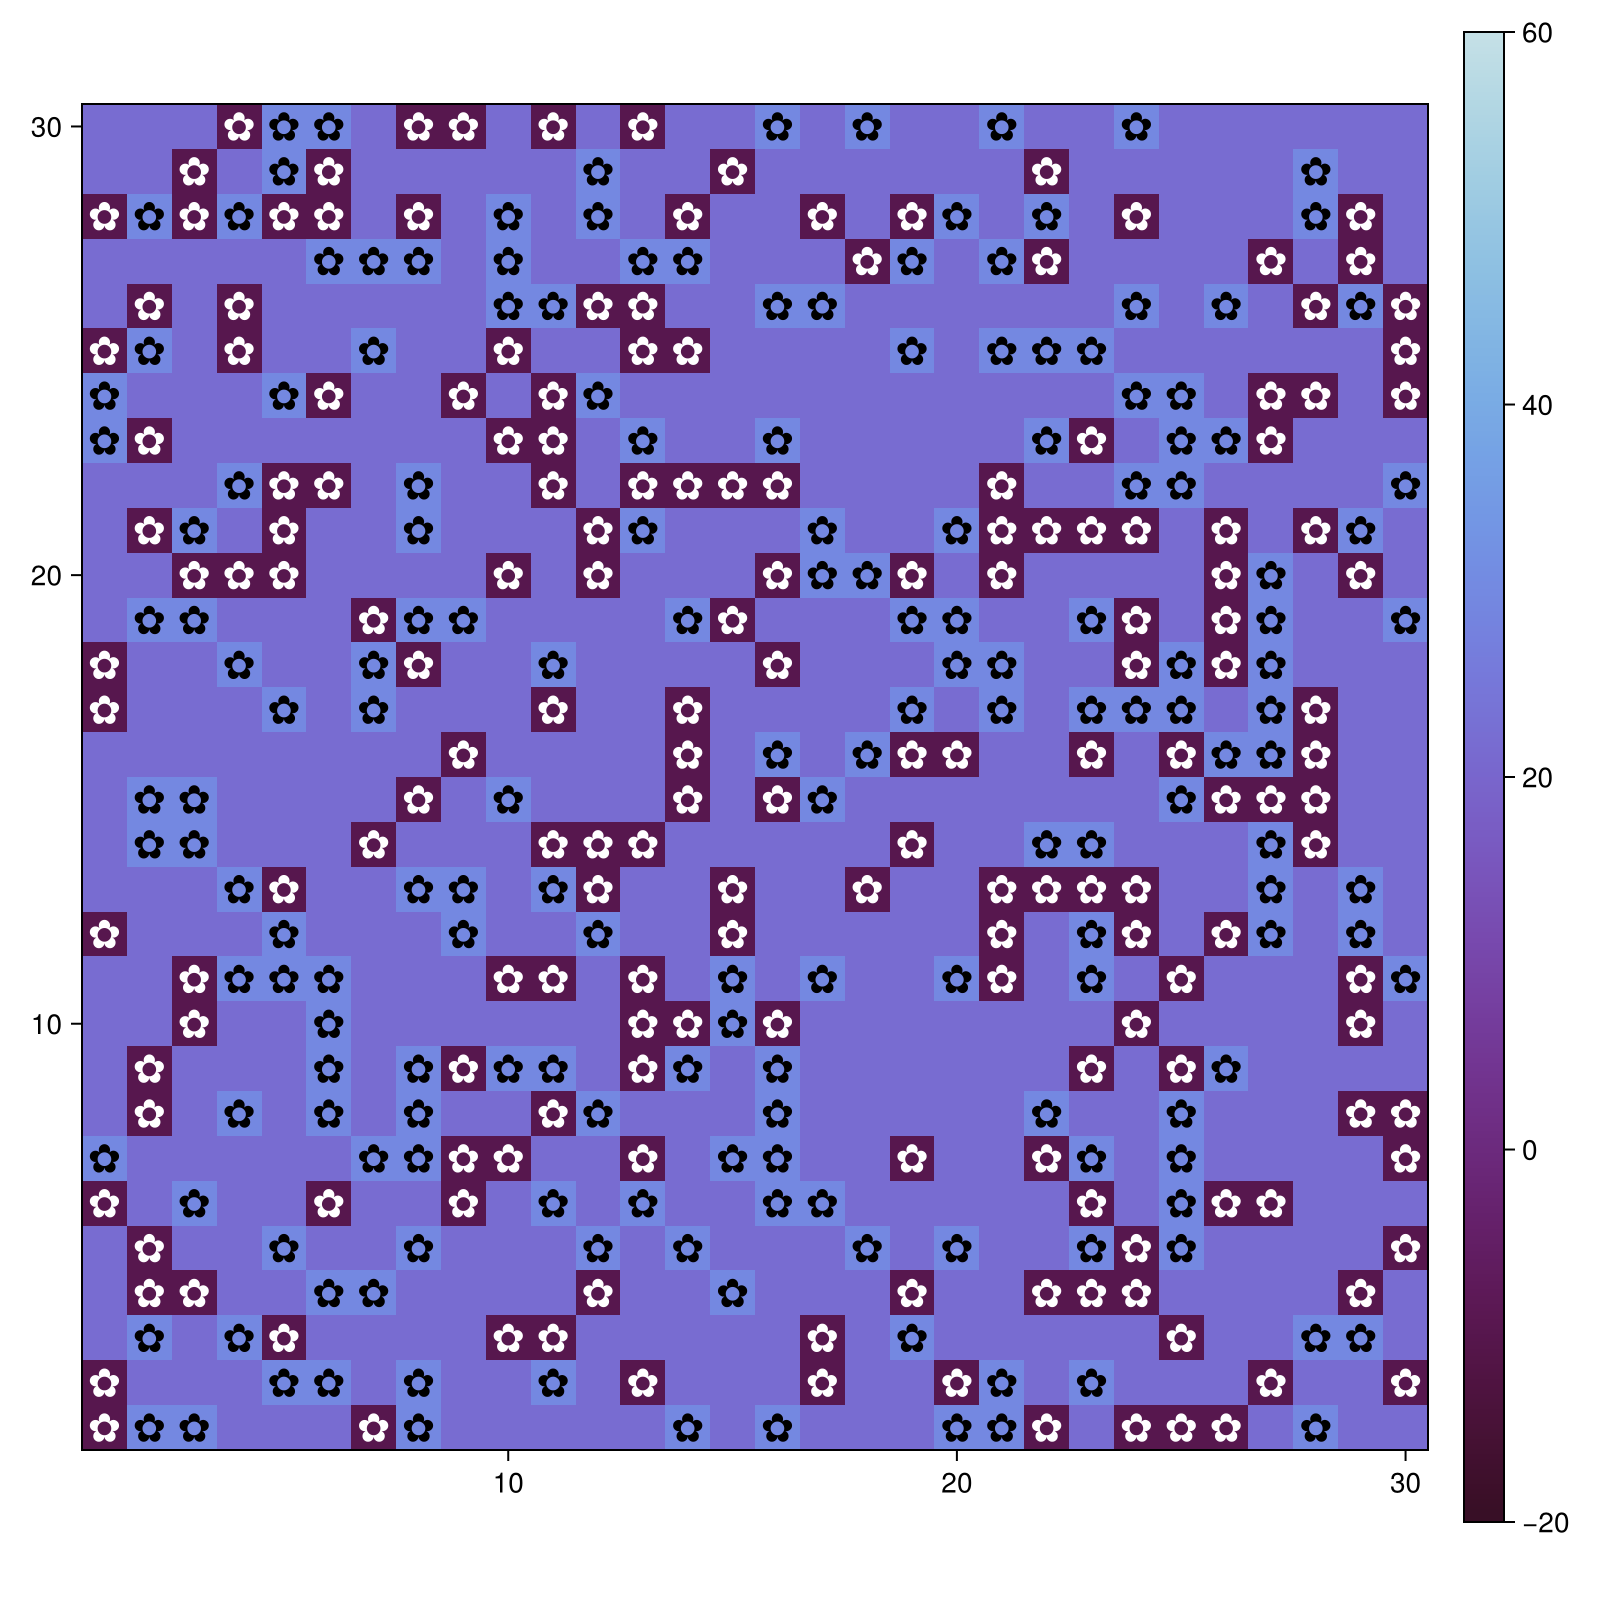

In [5]:
plt1, _ = abmplot(model; plotkwargs...)
plt1

## Состояние через 5 шагов

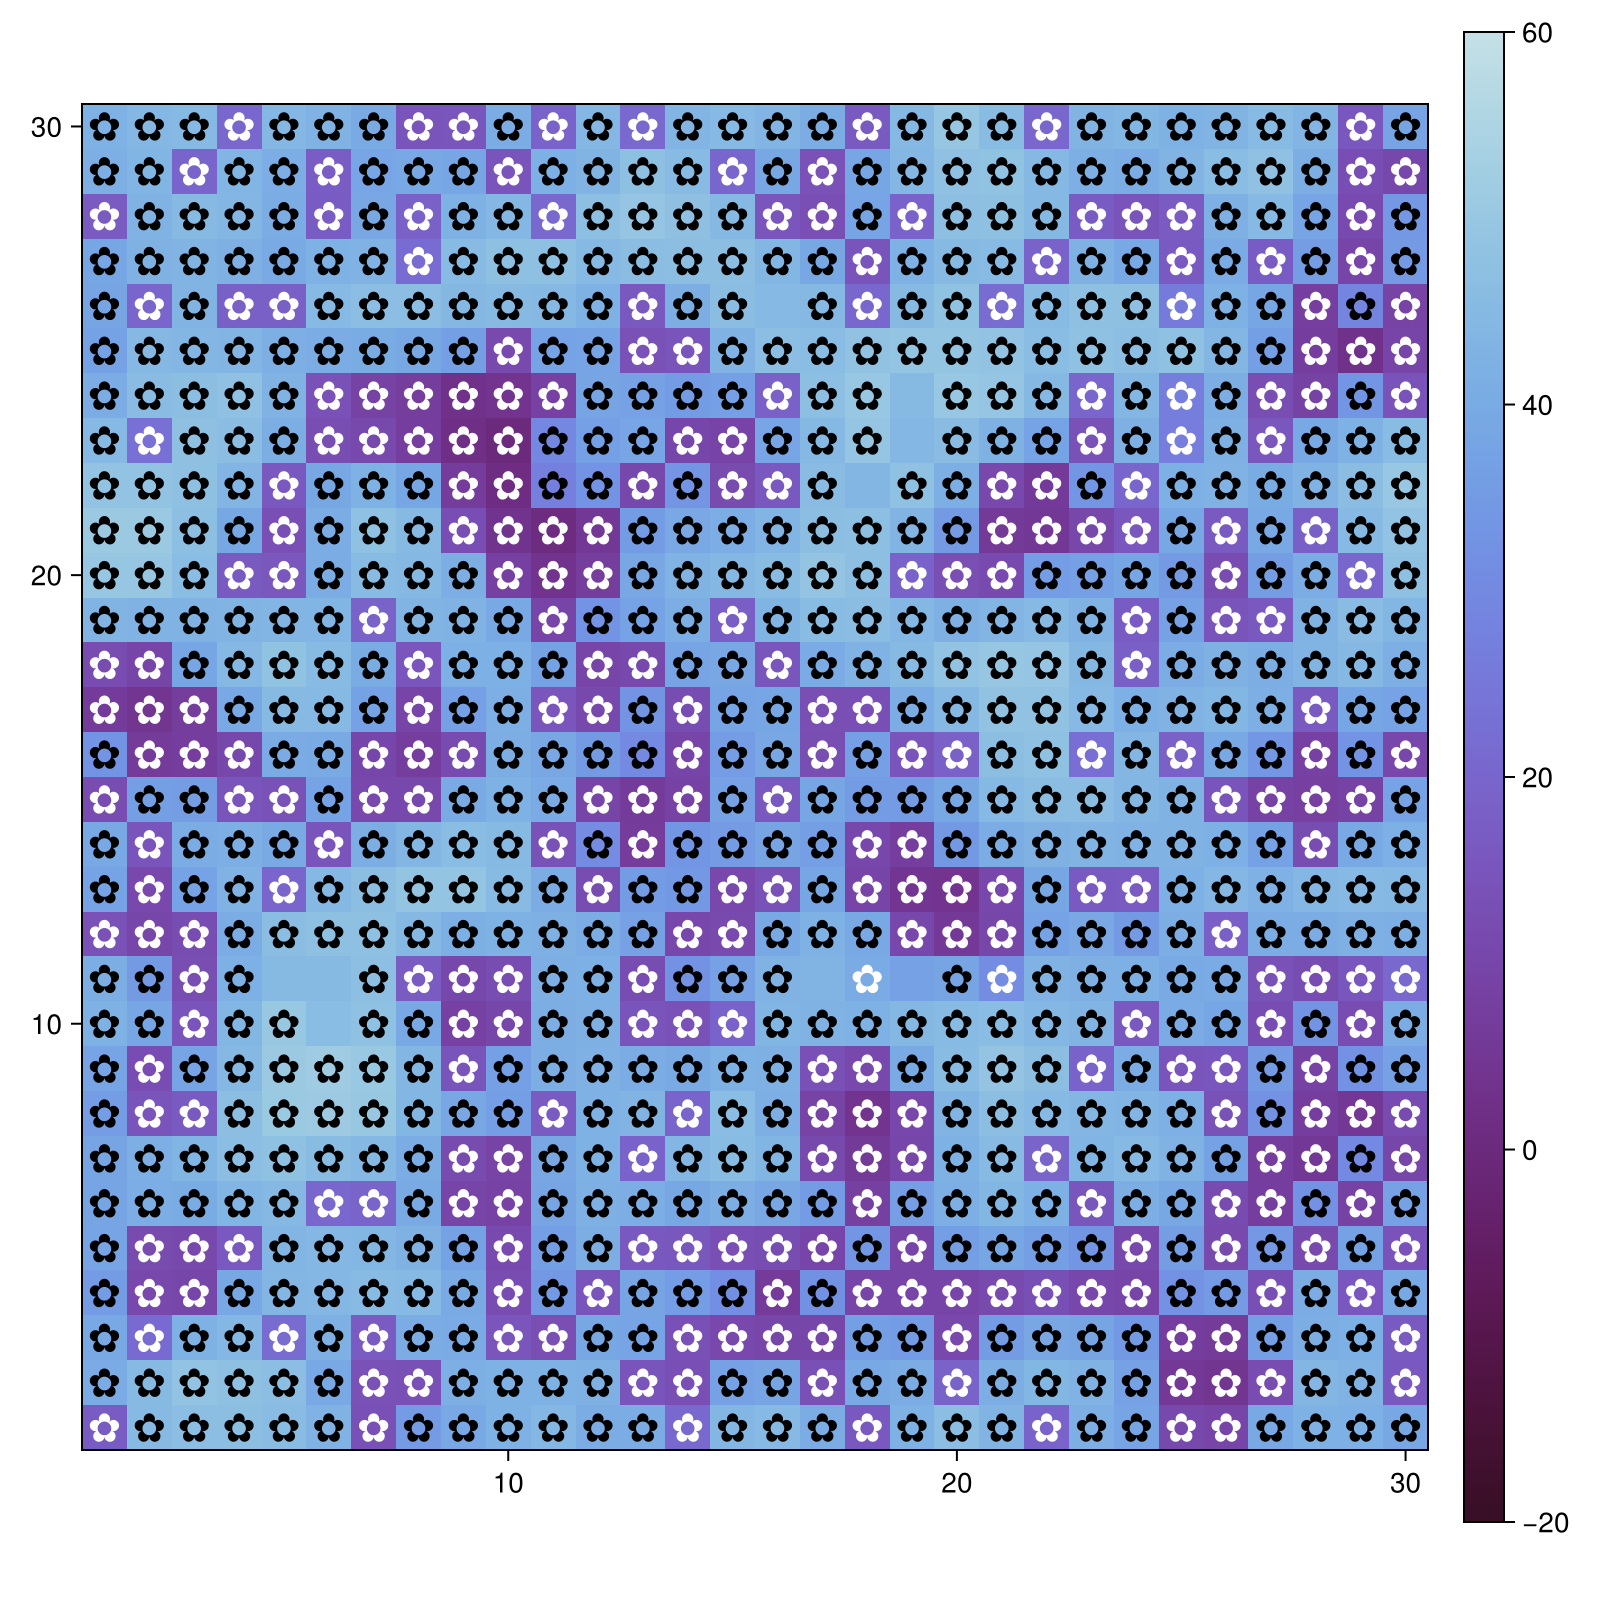

In [6]:
step!(model, 5)
plt2, _ = abmplot(model; plotkwargs...)
plt2

## Состояние ещё через 40 шагов

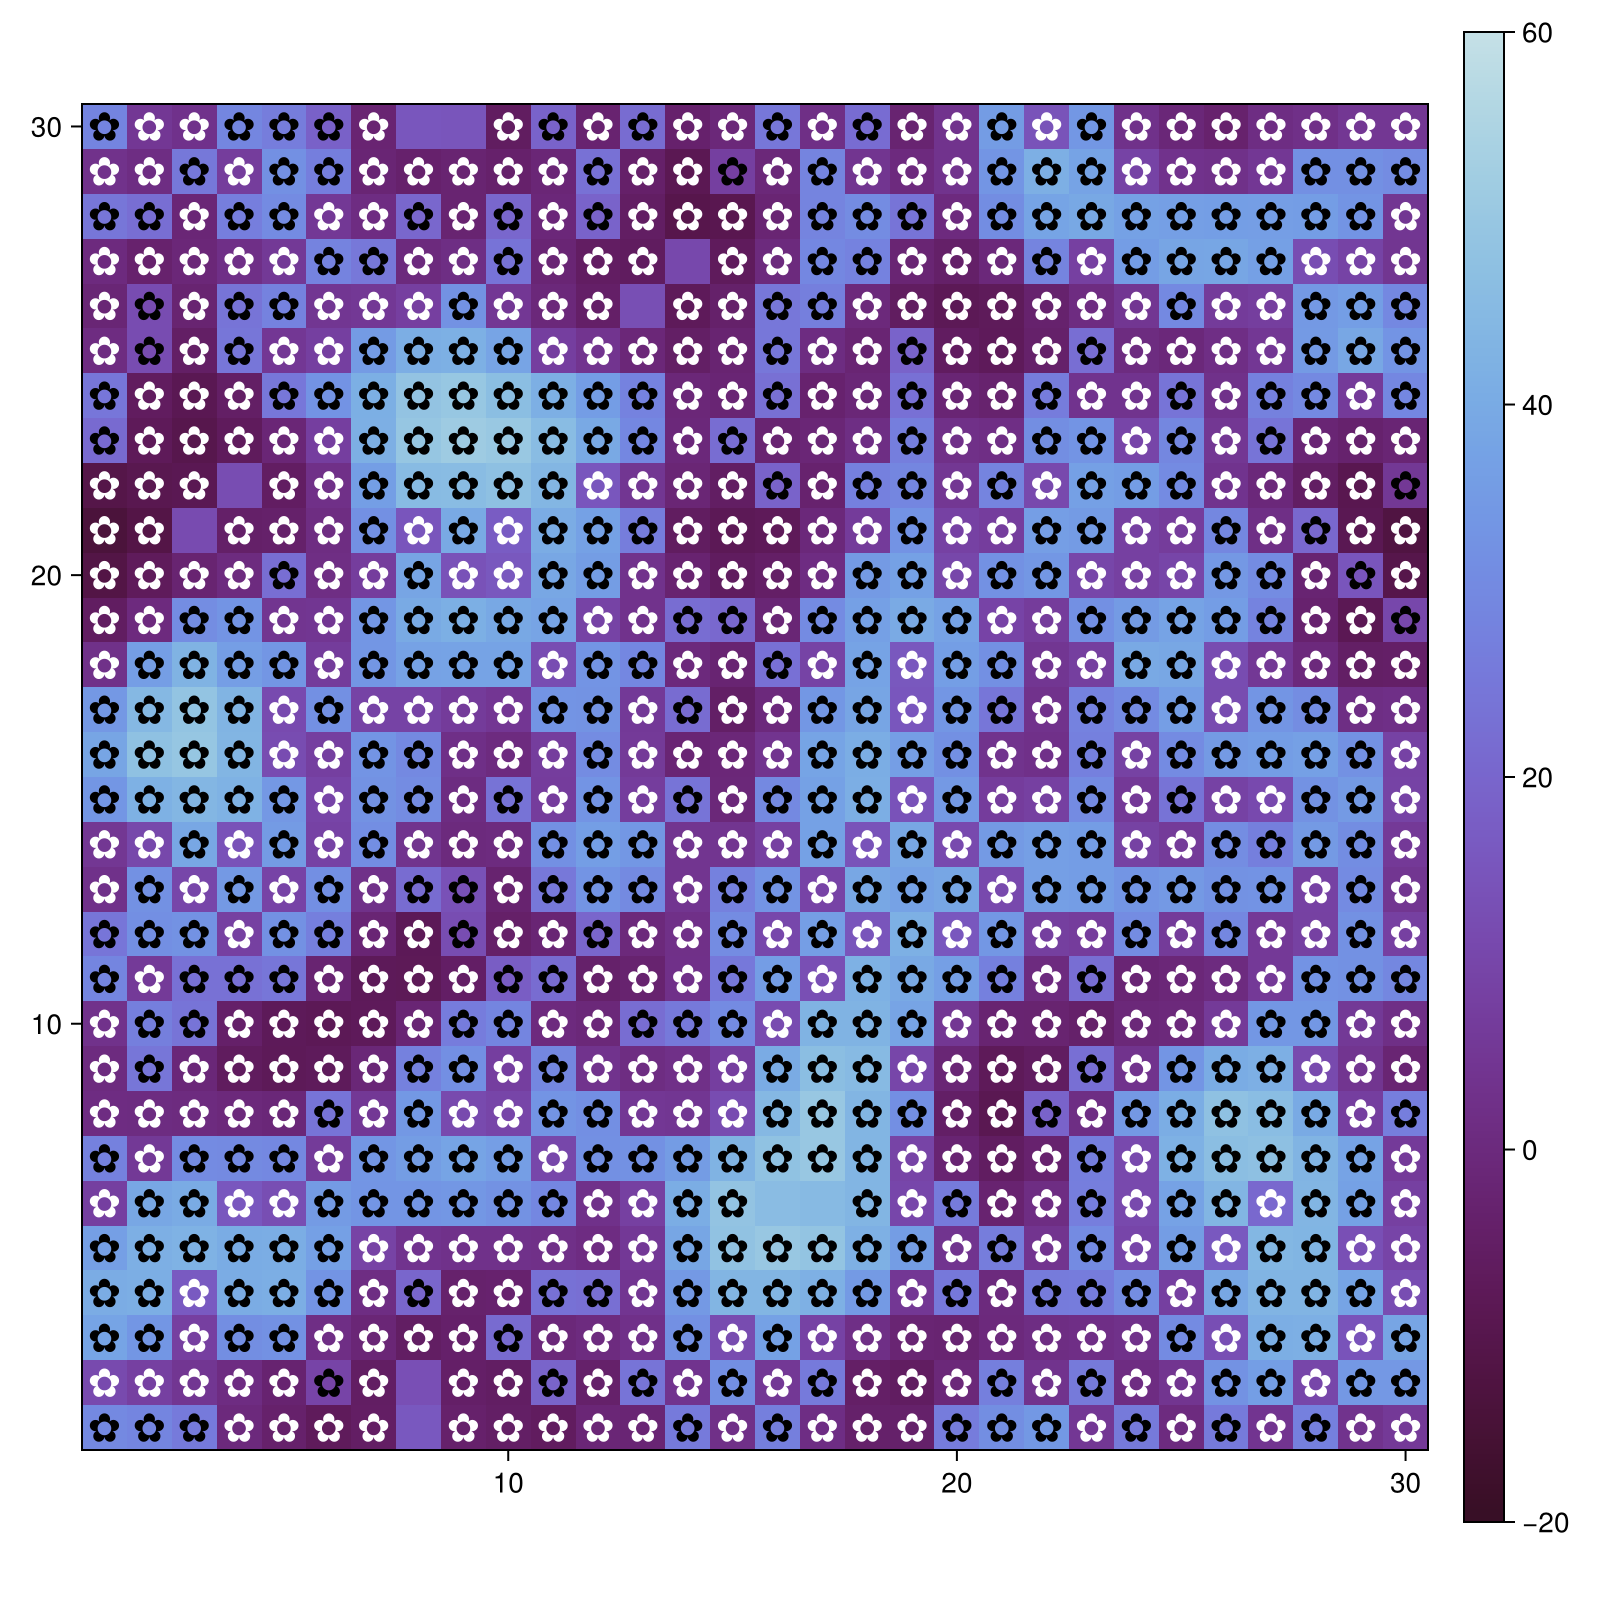

In [7]:
step!(model, 40)
plt3, _ = abmplot(model; plotkwargs...)
plt3

## Сохранение графиков

In [8]:
save(plotsdir("daisy_step001.png"), plt1)
save(plotsdir("daisy_step005.png"), plt2)
save(plotsdir("daisy_step040.png"), plt3)